<a href="https://colab.research.google.com/github/manidharc7/ISI-2026-Group1-Property-Valuation/blob/main/ISI_Project_Property_Valuation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# !pip install -q scikit-learn pandas numpy matplotlib joblib groq

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

print("setup ok")

setup ok


In [5]:
df_raw = pd.read_csv("/AmesHousing.csv")

print("shape:", df_raw.shape)
print(df_raw.columns.tolist()[:12])

df_raw[["Overall Qual", "Gr Liv Area", "Year Built", "Neighborhood", "SalePrice"]].head()

shape: (2930, 82)
['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config']


,Overall Qual,Gr Liv Area,Year Built,Neighborhood,SalePrice
0,6,1656,1960,NAmes,215000
1,5,896,1961,NAmes,105000
2,6,1329,1958,NAmes,172000
3,7,2110,1968,NAmes,244000
4,5,1629,1997,Gilbert,189900


In [6]:
before = len(df_raw)
df = df_raw[df_raw["Gr Liv Area"] <= 4000].copy()
print(f"dropped {before - len(df)} outliers; rows now {len(df)}")

NUMERIC = [
    "Overall Qual",
    "Gr Liv Area",
    "Total Bsmt SF",
    "Garage Cars",
    "Garage Area",
    "Year Built",
    "Year Remod/Add",
    "Full Bath",
    "TotRms AbvGrd",
    "1st Flr SF",
    "Lot Area",
    "Fireplaces",
    "Bedroom AbvGr",
]

CATEGORICAL = ["Neighborhood"]
TARGET = "SalePrice"
FEATURES = NUMERIC + CATEGORICAL

X = df[FEATURES].copy()
y = df[TARGET].copy()

print("X:", X.shape, " y:", y.shape)
print("SalePrice in X?", TARGET in X.columns)

dropped 5 outliers; rows now 2925
X: (2925, 14)  y: (2925,)
SalePrice in X? False


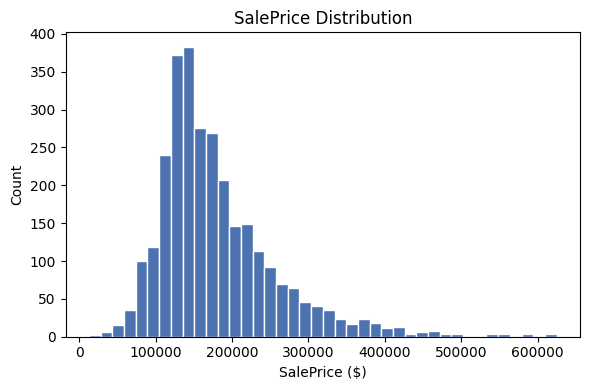

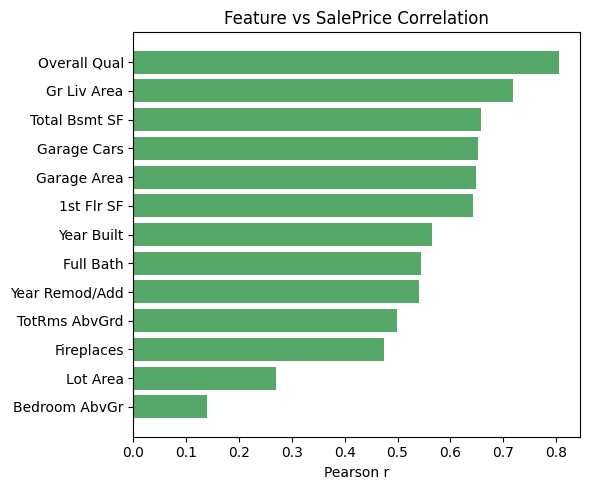

Overall Qual      0.81
Gr Liv Area       0.72
Total Bsmt SF     0.66
Garage Cars       0.65
Garage Area       0.65
1st Flr SF        0.64
Year Built        0.57
Full Bath         0.54
Year Remod/Add    0.54
TotRms AbvGrd     0.50
Fireplaces        0.47
Lot Area          0.27
Bedroom AbvGr     0.14
Name: SalePrice, dtype: float64


In [7]:
# price distribution
plt.figure(figsize=(6, 4))
plt.hist(y, bins=40, color="#4C72B0", edgecolor="white")
plt.title("SalePrice Distribution")
plt.xlabel("SalePrice ($)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

corr = df[NUMERIC + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()
plt.figure(figsize=(6, 5))
plt.barh(corr.index, corr.values, color="#55A868")
plt.title("Feature vs SalePrice Correlation")
plt.xlabel("Pearson r")
plt.tight_layout()
plt.show()

print(corr.sort_values(ascending=False).round(2))

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"train={len(X_train)} test={len(X_test)}")

num_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

cat_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, NUMERIC),
    ("cat", cat_pipe, CATEGORICAL)
])

print("preprocessor ready")

train=2340 test=585
preprocessor ready


In [9]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

lr_model = Pipeline([
    ("prep", preprocessor),
    ("model", LinearRegression())
])

lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_metrics = {
    "rmse": rmse(y_test, lr_pred),
    "mae": float(mean_absolute_error(y_test, lr_pred)),
    "r2": float(r2_score(y_test, lr_pred))
}

print(f"RMSE=${lr_metrics['rmse']:,.0f}  MAE=${lr_metrics['mae']:,.0f}  R²={lr_metrics['r2']:.3f}")

RMSE=$29,581  MAE=$19,153  R²=0.877
